# CREDIT RISK

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [23]:
V0 = 100. #assets today
D = 50. #debt
sV = 0.25 #volatility of assets
r = 0.03 #risk-free rate


$$ d_2(t) = \frac{1}{\sigma \sqrt{t}} \left( \frac{V_t}{D} + \left(r - \frac{1}{2}\sigma^2 \right)t  \right)$$

$$ Q(t) := P(V_t> D) = \Phi(d_2(t))$$

$$ \lambda(t) = - \frac{d}{dt}ln(Q(t))$$

$$ y - r = \frac{1}{t} \left[ ln(D) - ln \left(D\Phi(d_2) +V_0 e^{rt} \Phi(-d_1) \right) \right]$$

$$ d_1(t) = d_2(t) + \sigma \sqrt{t}$$

The above follows from

$$ D e^{-y t} = B_t = e^{-rt} \left[D \Phi(d_2) + V_0 e^{rt} \Phi(-d_1) \right]$$

So $y$ is how much yield is required to cover your losses. A higher $y-r$ means that the bond is riskier

CVA is how much you have overpaid, $De^{-rt} - B_t = De^{-rt} \Phi(-d_2) -V_0 \Phi(-d_1)$

In [24]:
def d2(T):
    return (np.log(V0/D) + (r - 0.5*sV**2)*T)/(sV*np.sqrt(T))

def Q(T):
    return scipy.stats.norm.cdf(d2(T))

def hazard(T, h=1e-4):
    return -(np.log(Q(T+h)) - np.log(Q(T-h)))/(2*h)

def d1(T):
    return d2(T) + sV*np.sqrt(T)

def credit_spread(T):
    return (1/T)*(np.log(D) - np.log(D*Q(T) + V0*np.exp(r*T)*scipy.stats.norm.cdf(-d1(T))))

def CVA(T):
    return D*np.exp(-r*T)*scipy.stats.norm.cdf(-d2(T)) - V0*scipy.stats.norm.cdf(-d1(T))


In [40]:
Ts = np.array([0.25, 0.5, 1, 3,5,7,10,15,20,35,50])
Qs = Q(Ts)
lambdas = hazard(Ts)
credit_spreads = credit_spread(Ts)
CVAs = CVA(Ts)


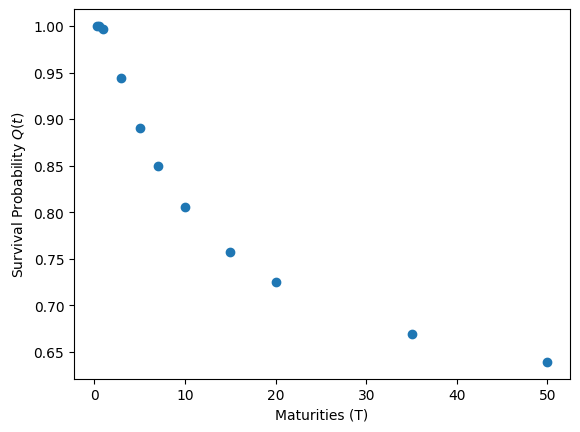

In [41]:
plt.scatter(Ts, Qs)
plt.xlabel('Maturities (T)')
plt.ylabel('Survival Probability '+r'$Q(t)$')
plt.show()


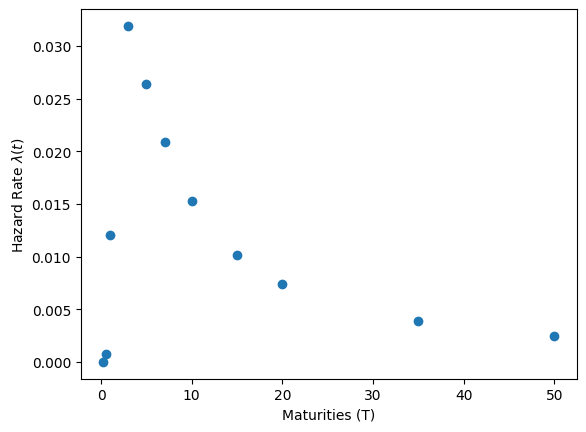

In [42]:
plt.scatter(Ts, lambdas)
plt.xlabel('Maturities (T)')
plt.ylabel('Hazard Rate '+ r'$\lambda(t)$')
plt.show()

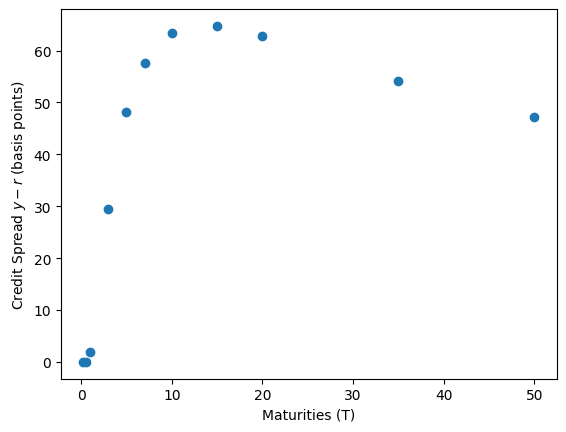

In [43]:
plt.scatter(Ts, credit_spreads*1e4)
plt.xlabel('Maturities (T)')
plt.ylabel('Credit Spread '+r'$y-r$'+' (basis points)')
plt.show()

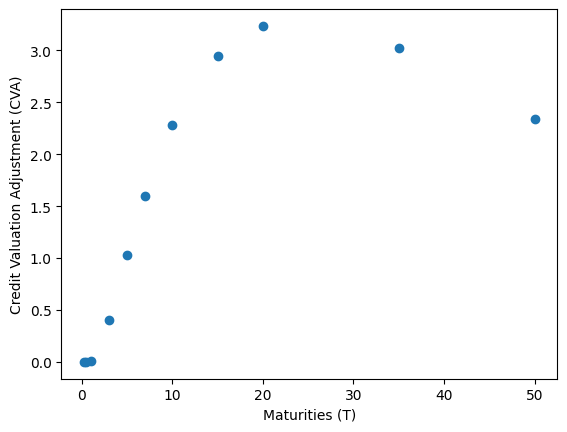

In [44]:
plt.scatter(Ts, CVAs)
plt.xlabel('Maturities (T)')
plt.ylabel('Credit Valuation Adjustment (CVA)')
plt.show()

## Plots

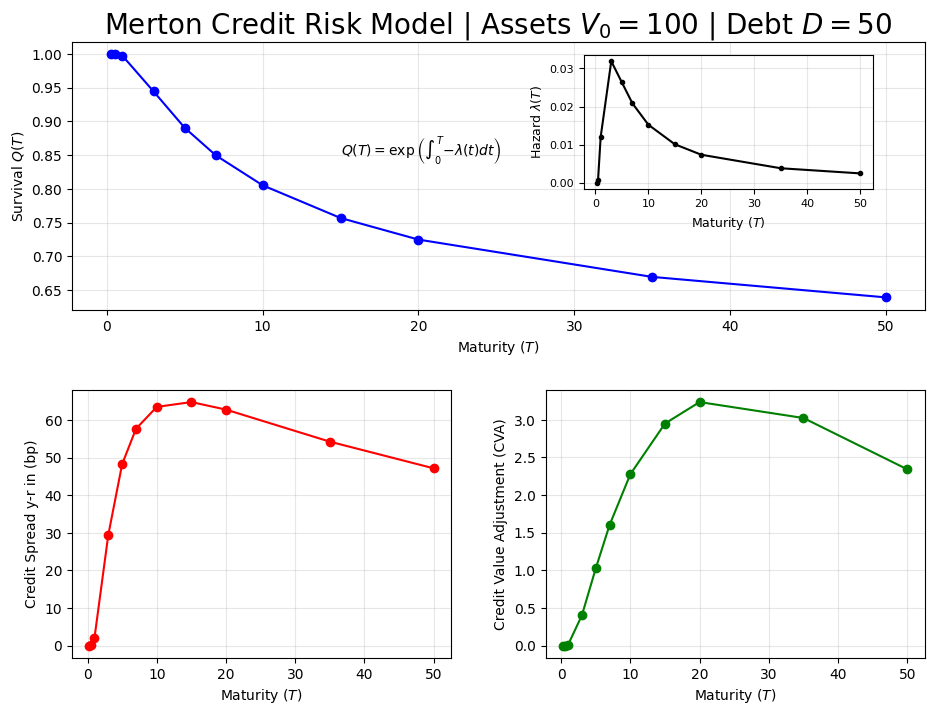

In [82]:

fig = plt.figure(figsize=(11, 8))
gs  = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

ax0 = fig.add_subplot(gs[0, :])      # top row, spans both columns
ax1 = fig.add_subplot(gs[1, 0])      # bottom left
ax2 = fig.add_subplot(gs[1, 1])      # bottom right

ax0.set_title('Merton Credit Risk Model | Assets '+r'$V_0=100$'+' | Debt '+ r'$ D=50$', fontsize=20)
ax0.plot(Ts, Qs, 'o-', c='blue')
ax0.grid(alpha=0.3)
axi = ax0.inset_axes([0.6, 0.45, 0.34, 0.5])   # [left, bottom, w, h] in axes fraction

axi.plot(Ts, lambdas, 'o-', ms=3, c='black')
axi.set_xlabel(r'Maturity $(T)$', fontsize=9)
axi.set_ylabel(r'Hazard $\lambda(T)$', fontsize=9)
axi.tick_params(labelsize=8)
axi.grid(alpha=0.3)

ax0.annotate(r'$Q(T) = \exp\left(\int_0^T {-\lambda(t)}dt\right)$', (15,0.85), fontsize=10)
ax0.set_xlabel('Maturity $(T)$'); ax0.set_ylabel(r'Survival $Q(T)$')

ax1.plot(Ts, credit_spreads*1e4, 'o-', c='red')
ax1.set_xlabel('Maturity $(T)$'); ax1.set_ylabel('Credit Spread y-r in (bp)')
ax1.grid(alpha=0.3)
ax2.plot(Ts, CVAs, 'o-', c='green')
ax2.set_xlabel('Maturity $(T)$'); ax2.set_ylabel('Credit Value Adjustment (CVA)')
ax2.grid(alpha=0.3)
plt.show()